# Basis Vectors and Matrix Columns

## Purpose

Understand that a matrix is defined by where it sends the basis vectors.

This is one of the most important ideas in the matrix-as-transformation view.

## Helpers

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def setup_vector_plot(xlim=(-5, 5), ylim=(-5, 5), figsize=(5.5, 5.5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    return fig, ax


def draw_vector(
    ax,
    v,
    origin=(0, 0),
    label=None,
    label_offset=(0.1, 0.1),
    width=0.007,
):
    origin = np.array(origin, dtype=float)
    v = np.array(v, dtype=float)

    ax.quiver(
        origin[0],
        origin[1],
        v[0],
        v[1],
        angles="xy",
        scale_units="xy",
        scale=1,
        width=width,
    )

    if label:
        end = origin + v
        ax.text(
            end[0] + label_offset[0],
            end[1] + label_offset[1],
            label,
            fontsize=10,
        )


def draw_transformation(ax, original, transformed, original_label="v", transformed_label="A @ v"):
    draw_vector(ax, original, label=original_label, label_offset=(0.1, 0.1))
    draw_vector(ax, transformed, label=transformed_label, label_offset=(0.1, -0.35), width=0.01)

## The standard basis vectors

In 2D, the standard basis vectors are:

$$
e_1 = [1, 0]
$$

and:

$$
e_2 = [0, 1]
$$

They point along the x-axis and y-axis.

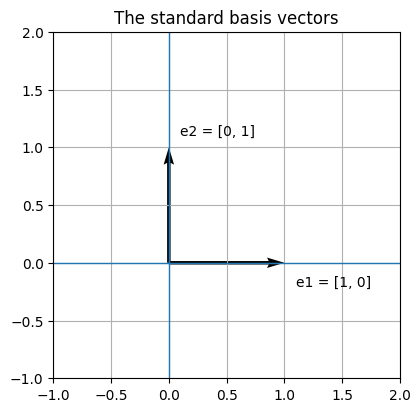

In [2]:
e1 = np.array([1, 0])
e2 = np.array([0, 1])

fig, ax = setup_vector_plot(xlim=(-1, 2), ylim=(-1, 2), figsize=(4.5, 4.5))

draw_vector(ax, e1, label="e1 = [1, 0]", label_offset=(0.1, -0.2), width=0.01)
draw_vector(ax, e2, label="e2 = [0, 1]", label_offset=(0.1, 0.1), width=0.01)

ax.set_title("The standard basis vectors")
plt.show()

The basis vectors are useful because any 2D vector can be built from them.

For example:

$$
[3, 2] = 3e_1 + 2e_2
$$

In [3]:
v = np.array([3, 2])

rebuilt_v = 3 * e1 + 2 * e2

print("v:", v)
print("3 * e1 + 2 * e2:", rebuilt_v)

v: [3 2]
3 * e1 + 2 * e2: [3 2]


## Transforming the basis vectors

Now apply a matrix to the basis vectors.

Use this matrix:

$$
A =
\begin{bmatrix}
2 & 1 \\
1 & 3
\end{bmatrix}
$$

In [4]:
A = np.array([
    [2, 1],
    [1, 3],
])

Ae1 = A @ e1
Ae2 = A @ e2

print("A:")
print(A)
print()
print("A @ e1:", Ae1)
print("A @ e2:", Ae2)

A:
[[2 1]
 [1 3]]

A @ e1: [2 1]
A @ e2: [1 3]


Notice something important:

$$
A e_1
$$

is the first column of \(A\).

And:

$$
A e_2
$$

is the second column of \(A\).

In [5]:
first_column = A[:, 0]
second_column = A[:, 1]

print("first column:", first_column)
print("A @ e1:", Ae1)
print()
print("second column:", second_column)
print("A @ e2:", Ae2)

first column: [2 1]
A @ e1: [2 1]

second column: [1 3]
A @ e2: [1 3]


## The columns of a matrix

The columns of a matrix tell us where the basis vectors go.

For:

$$
A =
\begin{bmatrix}
2 & 1 \\
1 & 3
\end{bmatrix}
$$

the first column is:

$$
[2, 1]
$$

so \(e_1\) gets transformed to \([2, 1]\).

The second column is:

$$
[1, 3]
$$

so \(e_2\) gets transformed to \([1, 3]\).

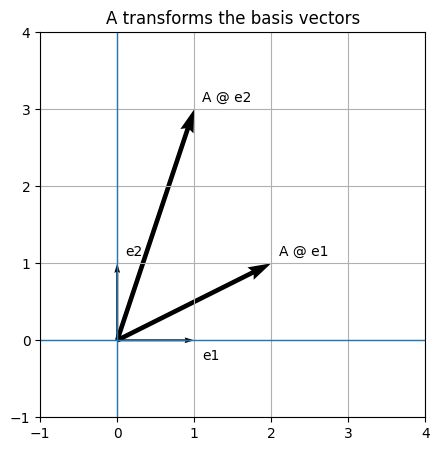

In [6]:
fig, ax = setup_vector_plot(xlim=(-1, 4), ylim=(-1, 4), figsize=(5, 5))

draw_vector(ax, e1, label="e1", label_offset=(0.1, -0.25), width=0.005)
draw_vector(ax, e2, label="e2", label_offset=(0.1, 0.1), width=0.005)

draw_vector(ax, Ae1, label="A @ e1", label_offset=(0.1, 0.1), width=0.012)
draw_vector(ax, Ae2, label="A @ e2", label_offset=(0.1, 0.1), width=0.012)

ax.set_title("A transforms the basis vectors")
plt.show()

## Rebuilding \(A @ v\) from transformed basis vectors

Since:

$$
v = 3e_1 + 2e_2
$$

then:

$$
A v = 3(Ae_1) + 2(Ae_2)
$$

The matrix transforms the basis vectors, then the vector's components tell us how much of each transformed basis vector to use.

In [7]:
v = np.array([3, 2])

direct_result = A @ v
basis_result = 3 * (A @ e1) + 2 * (A @ e2)

print("A @ v:", direct_result)
print("3 * (A @ e1) + 2 * (A @ e2):", basis_result)

A @ v: [8 9]
3 * (A @ e1) + 2 * (A @ e2): [8 9]


The two results are the same.

## A matrix as a new coordinate frame

This is a useful mental model:

> A matrix transforms the coordinate frame by moving the basis vectors.

The transformed basis vectors tell us what the matrix does to the whole plane.

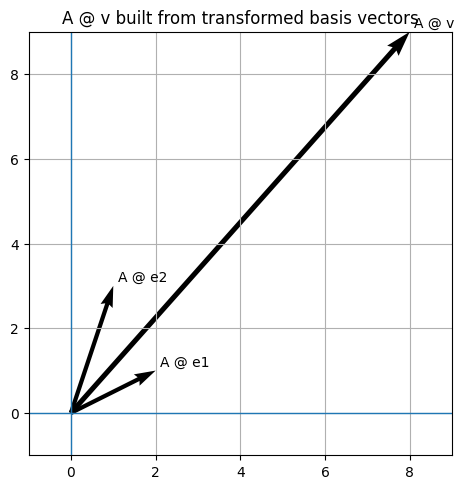

In [8]:
v = np.array([3, 2])
Av = A @ v

fig, ax = setup_vector_plot(xlim=(-1, 9), ylim=(-1, 9), figsize=(5.5, 5.5))

draw_vector(ax, Ae1, label="A @ e1", label_offset=(0.1, 0.1), width=0.01)
draw_vector(ax, Ae2, label="A @ e2", label_offset=(0.1, 0.1), width=0.01)
draw_vector(ax, Av, label="A @ v", label_offset=(0.1, 0.1), width=0.012)

ax.set_title("A @ v built from transformed basis vectors")
plt.show()

## Summary

- The standard basis vectors are \(e_1 = [1, 0]\) and \(e_2 = [0, 1]\).
- Any 2D vector can be built from the basis vectors.
- The columns of a matrix show where the basis vectors go.
- This means a matrix is fully described by its transformed basis vectors.
- \(A v\) can be understood as recombining the transformed basis vectors.

## Next step

Next, we will apply matrix transformations to whole shapes.